(sec:alpha)=
# Polarizability

The linear electric-dipole polarizabilty is determined from the linear response function 

$$
\alpha_{\alpha\beta}(\omega) =
- 
\langle\langle \hat{\mu}_\alpha; \hat{\mu}_\beta 
\rangle \rangle_\omega
$$

where $\hat{\mu}_\alpha$ is the electric-dipole operator along Cartesian coordinate $\alpha$ and $\omega$ is the optical angular frequency. 

At optical frequencies well separated from transition frequencies in the system, the polarizability is real, whereas in near-resonance or resonance regions of the spectrum, it becomes complex. For further theoretical details, see {cite}`Norman2018`.

## Nonresonant region

**Python script**

In [ ]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("methane")
basis = vlx.MolecularBasis.read(molecule, "def2-svpd")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

lr_drv = vlx.LinearResponseDriver()

lr_drv.property = "polarizability"
lr_drv.frequencies = [0.0656]  # static field is default

lr_results = lr_drv.compute(molecule, basis, scf_results)

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
basis: aug-cc-pvdz
@end

@response
property: polarizability
frequencies: 0-0.25 (0.05)
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end 
:::

The frequencies of the perturbing electric field is specified as a `list` in the Python script input file and as a frequency region with a frequency point separation in parenthesis in the text file input.

## Resonant region

In [7]:
import numpy as np
import veloxchem as vlx

molecule = vlx.Molecule.read_molecule_string("""
C        0.67759997    0.00000000    0.00000000
C       -0.67759997    0.00000000    0.00000000
H        1.21655197    0.92414474    0.00000000
H        1.21655197   -0.92414474    0.00000000
H       -1.21655197   -0.92414474    0.00000000
H       -1.21655197    0.92414474    0.00000000
""")
basis = vlx.MolecularBasis.read(molecule, "def2-svpd")

scf_drv = vlx.ScfRestrictedDriver()

scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

crs = vlx.ComplexResponse()

# to be implemented (together with a plot function)
#crs.property = "polarizability"

crs.a_operator = "electric dipole"
crs.b_operator = "electric dipole"

crs.a_components = ["x"]
crs.b_components = ["x"]

crs.frequencies = np.arange(0.0, 0.4, 0.0025)

crs_results = crs.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

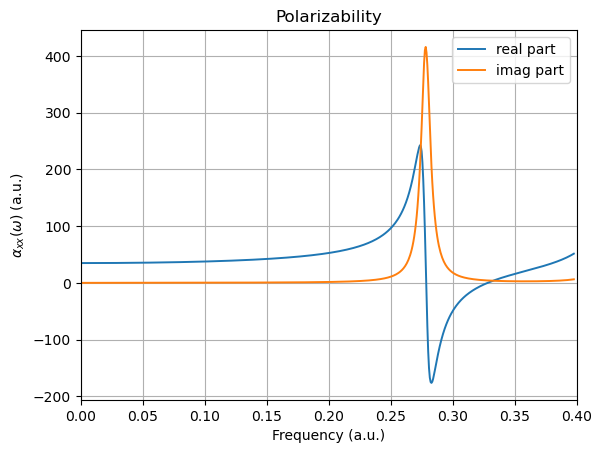

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

alpha_real = []
alpha_imag = []

# Extract response functions
for key, lrf in crs_results["response_functions"].items():
    alpha_real.append(-lrf.real)
    alpha_imag.append(-lrf.imag)

alpha_real = np.array(alpha_real)
alpha_imag = np.array(alpha_imag)

freqs = np.array(crs.frequencies)

# Cubic spline interpolation
cs_real = CubicSpline(freqs, alpha_real)
cs_imag = CubicSpline(freqs, alpha_imag)

# Dense grid for smooth curves
f_dense = np.linspace(freqs.min(), freqs.max(), 600)

# Create figure and axis
fig, ax = plt.subplots()

# --- Smooth cubic-spline curves ---
ax.plot(f_dense, cs_real(f_dense), '-', linewidth=1.4, label="real part")
ax.plot(f_dense, cs_imag(f_dense), '-', linewidth=1.4, label="imag part")

ax.set_xlim(0, 0.4)
plt.title("Polarizability")
ax.set_xlabel("Frequency (a.u.)")
ax.set_ylabel(r"$\alpha_{xx}(\omega)$ (a.u.)")
ax.grid(True)
ax.legend()

plt.show()

## Laser pulse propagation

VeloxChem allows for calculation of the linear response to a Gaussian-envelope pulse.

The time-domain shape parameters for this pulse may be specified by the user, optionally storing a collection of pertinent results in an HDF5-formatted file or a plain text ASCII file whose name may be specified by the user.

An example of an input file that when run will carry out such a calculation is given below. Note in particular that the default of carrier envelope phase may need adjustment to match your desired setup.

```
@jobs
task: pulses
@end

@method settings
basis: aug-cc-pvdz
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end

@pulses
envelope: gaussian
field_max : 1.0e-5
number_pulses: 1
centers: 300 
field_cutoff_ratio: 1e-5
frequency_range : 0.2-0.4(0.001)
carrier_frequencies: 0.325
pulse_widths: 50 
pol_dir: xyz
h5 : pulsed
ascii : pulsed
@end
```

If HDF5-formatted data was produced during this calculation, that data may used for plot generation using the script located at `utils/pulsed_response_plot.py` from the VeloxChem root folder.

Also note that other standard python modules such as `matplotlib` must be installed on the system from which this script is run. The script will take the HDF5-formatted data produced during the VeloxChem calculation and generate a plot of the real and imaginary frequency-domain electric dipole polarizability, a representation of the perturbing field in the frequency domain, the resulting (real-valued) first-order dipole moment correction in the time domain and a representation of the perturbing field in the time domain.

For more information and further description of how to run this script, please consult the documentation written inside it.